In [3]:
#!/usr/bin/python3

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime

# path = "BP、SVR、ELM三种常见单一对比模型-单输入/数据.txt"  # 数据集路径
df = pd.read_excel('data_3228.xlsx')
f = df['Price'].values

In [4]:
series = df['Price'].values
series

array([14.7, 14.7, 14.6, ..., 13.8, 13.8, 13.8])

In [5]:

# series = series - np.mean(series)   # 中心化(非必须)
series

array([14.7, 14.7, 14.6, ..., 13.8, 13.8, 13.8])

In [6]:
# step1 嵌入
windowLen = 6           # 嵌入窗口长度
seriesLen = len(series)     # 序列长度
print(seriesLen,'lenlen')
K = seriesLen - windowLen + 1
X = np.zeros((windowLen, K))
for i in range(K):
    X[:, i] = series[i:i + windowLen]

3228 lenlen


In [7]:
# step2: svd分解， U和sigma已经按升序排序
U, sigma, VT = np.linalg.svd(X, full_matrices=False)

for i in range(VT.shape[0]):
    VT[i, :] *= sigma[i]
A = VT

In [8]:
# 重组
rec = np.zeros((windowLen, seriesLen))
for i in range(windowLen):
    for j in range(windowLen-1):
        for m in range(j+1):
            rec[i, j] += A[i, j-m] * U[m, i]
        rec[i, j] /= (j+1)
    for j in range(windowLen-1, seriesLen - windowLen + 1):
        for m in range(windowLen):
            rec[i, j] += A[i, j-m] * U[m, i]
        rec[i, j] /= windowLen
    for j in range(seriesLen - windowLen + 1, seriesLen):
        for m in range(j-seriesLen+windowLen, windowLen):
            rec[i, j] += A[i, j - m] * U[m, i]
        rec[i, j] /= (seriesLen - j)
        

In [9]:
rrr = np.sum(rec, axis=0)  # 选择重构的部分，这里选了全部
rrr

array([14.7, 14.7, 14.6, ..., 13.8, 13.8, 13.8])

In [10]:
# 计算残差值
residual = series - rrr
residual

array([-9.05941988e-14, -9.63140678e-12, -5.73585623e-12, ...,
       -2.46913601e-13, -2.41584530e-13, -2.38031816e-13])

In [11]:
# 将rec结果和残差值保存到excel中
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
df_rec = pd.DataFrame(rec.T, columns=[f"rec_{i}" for i in range(1, windowLen+1)])
df_res = pd.DataFrame(residual, columns=['residual'])
df_all = df.join([df_rec,df_res])
df_all.to_excel(f"结果/ssa_res_{timestamp}.xlsx", index=False)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


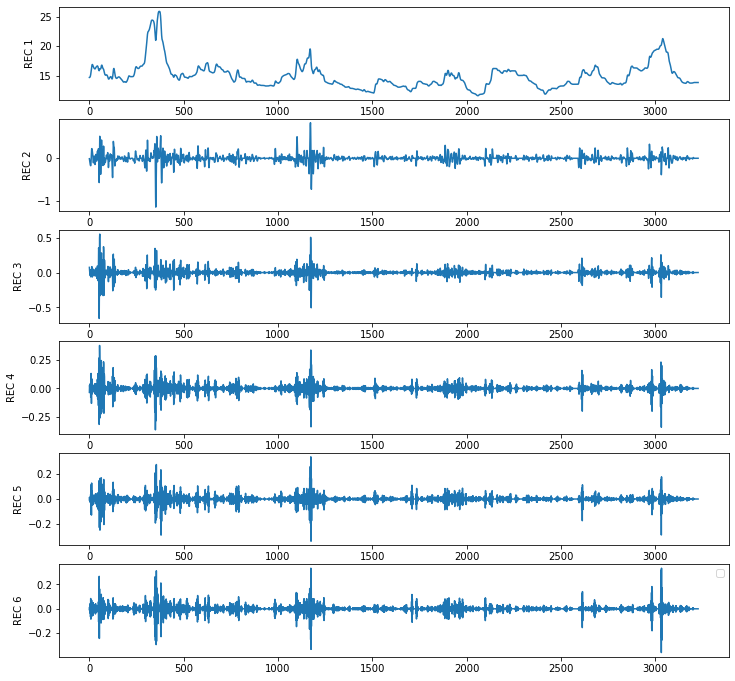

In [12]:

# 绘制图像
plt.figure(figsize=(12,14))
for i in range(windowLen):
    ax = plt.subplot(int(windowLen+1),1,i+1)
    ax.plot(rec[i, :])
    ax.set_ylabel(f'REC {i+1}')

# ax = plt.subplot(int(windowLen+1),2,windowLen+1)
# ax.plot(residual, label='Residual', color='red')
ax.legend()
plt.show()
